In [3]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np

def select_candidates(uids, fractions, n_models, alpha=0.05):
    """
    Description:
        Run BH-FDR-corrected one-sided binomial test against the median
        baseline, returning significant uids and the lowest passing fraction.

    Args:
        uids: List of identifiers, one per entry.
        fractions: List of observed proportions (e.g. NAC fractions).
        n_models: List of sample sizes (per entry).
        alpha: FDR level.

    Returns:
        Tuple (set of significant uids, lowest significant fraction or None).
    """

    baseline = np.median(fractions)
    pvals = [binomtest(int(f * n), n, p=baseline, alternative='greater').pvalue
             for f, n in zip(fractions, n_models)]
    rejected, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    candidates = {uids[i] for i in range(len(uids)) if rejected[i]}
    sig_fracs = [fractions[i] for i in range(len(uids)) if rejected[i]]
    threshold = min(sig_fracs) if sig_fracs else None
    return candidates, threshold


In [4]:
import pandas as pd

suffix = '2O'
result_path = f'./results/carA_homologs_nac_candidates_{suffix}.csv'

df = pd.read_csv(result_path)
df_conf = df[(df['n_confident_holo'] >= 30) & (df['n_confident_apo'] >= 30)]

df_conf

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A010YLP6,0.437500,1;3;4;5;8;10;11;13;14;16;18;20;30;32;34;35;37;...,48,2.598909,1.171320,0.32,3;4;5;7;8;10;12;16;18;19;27;31;45;46;49;50;55;...,100
1,A0A024JZE3,0.044444,11;20,45,2.392342,1.199905,0.22,8;11;15;27;34;36;44;51;56;59;61;63;67;68;73;82...,100
2,A0A024JZE8,0.266667,1;5;8;10;11;15;27;28;30;37;39;41,45,2.637136,1.484345,0.16,5;8;10;21;54;57;59;63;64;70;83;84;86;88;90;96,100
3,A0A045K2P5,0.211538,5;6;13;16;18;20;23;28;30;38;40,52,2.298625,1.193063,0.24,7;13;17;19;21;25;34;37;40;41;42;47;54;64;78;86...,100
4,A0A051U3G5,0.161290,2;6;12;22;23,31,2.989460,1.123785,0.26,4;10;19;21;28;39;41;42;43;51;54;69;70;73;74;75...,100
...,...,...,...,...,...,...,...,...,...
421,W7J139,0.490909,2;4;6;9;10;11;12;15;16;17;18;23;26;27;32;34;35...,55,2.245017,1.304602,0.66,1;2;4;5;7;8;10;11;12;13;15;17;18;19;20;23;24;2...,100
422,W9B0J1,0.157895,1;5;11;14;19;27;32;35;37,57,2.140178,1.256572,0.01,22,100
423,X0Q040,0.040000,11;29,50,2.378274,1.232604,0.00,NaN,100
424,X8A9W7,0.075472,8;43;48;49,53,2.305766,1.263219,0.18,5;21;26;41;49;54;61;62;63;69;70;76;79;90;92;93...,100


In [5]:

entries = df_conf['entry'].tolist()

nac_fraction_holo = df_conf['nac_fraction_holo'].tolist()
nac_fraction_apo = df_conf['nac_fraction_apo'].tolist()

n_conf_models_holo = df_conf['n_confident_holo'].tolist()
n_conf_models_apo = df_conf['n_confident_apo'].tolist()

sig_holo, thr_holo = select_candidates(entries, nac_fraction_holo, n_conf_models_holo)
sig_apo,  thr_apo  = select_candidates(entries, nac_fraction_apo,  n_conf_models_apo)
both = sig_holo & sig_apo

print(f"Holo:  {len(sig_holo):>3d} / {len(entries)}  (threshold: {thr_holo:.1%})")
print(f"Apo:   {len(sig_apo):>3d} / {len(entries)}  (threshold: {thr_apo:.1%})")
print(f"Both:  {len(both):>3d}")

Holo:  108 / 426  (threshold: 39.4%)
Apo:   183 / 426  (threshold: 44.0%)
Both:  100


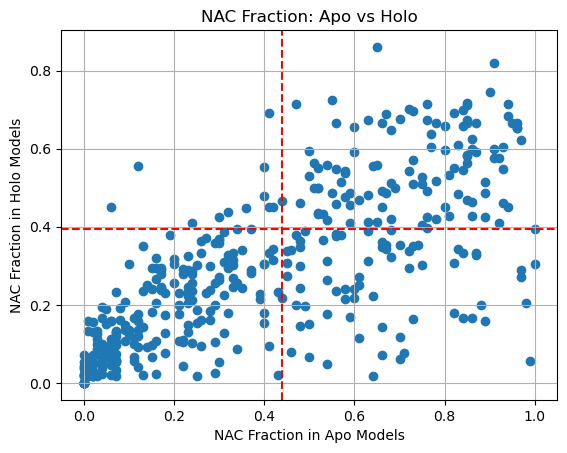

In [6]:
import matplotlib.pyplot as plt

plt.scatter(nac_fraction_apo, nac_fraction_holo)
plt.xlabel('NAC Fraction in Apo Models')
plt.ylabel('NAC Fraction in Holo Models')
plt.title('NAC Fraction: Apo vs Holo')
plt.axhline(y=thr_holo, color='r', linestyle='--', label=f'Threshold: {thr_holo:.2%}')
plt.axvline(x=thr_apo, color='r', linestyle='--', label=f'Threshold: {thr_apo:.2%}')

plt.grid(True)
plt.show()

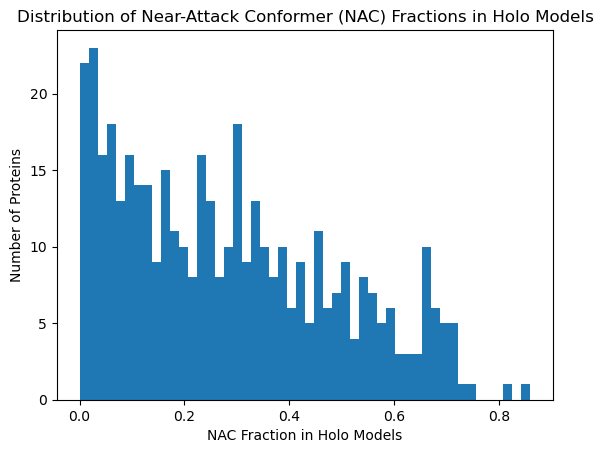

In [7]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_holo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

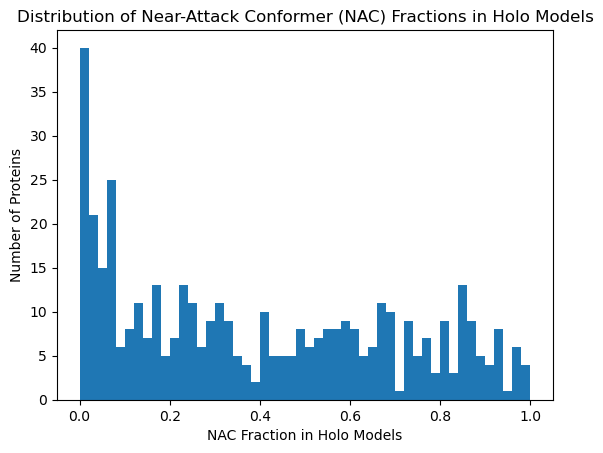

In [8]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_apo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

Split PLACER outputs into the models to satisfy NAC geometry
------------------------------------------------------------------------------

In [9]:
import os

cols = ['entry', 'nac_fraction_holo', 'nac_holo_idxs', 'n_confident_holo',
        'prmsd_mean', 'prmsd_std', 'nac_fraction_apo', 'nac_apo_idxs', 'n_confident_apo']

candidate_df = df_conf[df_conf['entry'].isin(both)].reset_index(drop=True)[cols]

candidate_df.to_csv(f'{os.path.splitext(result_path)[0]}_filtered.csv', index=False)
candidate_df

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A064CG00,0.647059,2;3;4;5;7;8;11;12;13;14;15;16;17;18;20;21;23;2...,34,2.966543,1.320483,0.68,1;2;3;6;8;9;10;11;12;13;14;15;18;19;21;22;23;2...,100
1,A0A0F5NA60,0.571429,4;6;8;10;12;13;14;15;17;18;19;20;21;22;23;24;2...,42,2.558705,1.200925,0.73,1;2;3;4;5;6;7;9;11;12;13;15;16;18;21;22;23;24;...,100
2,A0A0H3MCY6,0.517857,1;2;4;5;9;10;13;14;15;19;20;21;26;27;28;29;30;...,56,2.293562,1.297935,0.78,1;3;4;5;6;7;11;12;13;16;18;20;21;22;23;24;25;2...,100
3,A0A0I9Z3I8,0.652174,1;2;3;4;5;8;10;11;12;13;14;16;17;18;19;21;22;2...,46,2.373432,1.138223,0.96,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;17;18;19;2...,100
4,A0A0J6VZP7,0.547619,2;3;8;10;12;13;14;16;18;21;22;23;25;26;27;28;2...,42,2.571814,1.133964,0.56,2;3;6;9;11;12;16;17;20;21;22;23;24;30;31;34;38...,100
...,...,...,...,...,...,...,...,...,...
95,E5XP76,0.717949,2;3;5;7;8;9;10;12;13;14;16;18;19;20;21;22;23;2...,39,2.720116,1.225204,0.85,1;2;3;7;8;9;11;12;13;14;15;16;17;18;19;20;21;2...,100
96,H8IU56,0.487179,1;3;4;5;6;10;12;14;16;18;21;25;30;31;33;35;36;...,39,2.777208,1.252267,0.67,1;3;5;6;7;11;12;13;14;16;17;18;21;23;24;25;26;...,100
97,K0EY54,0.714286,2;3;4;5;6;7;8;9;10;12;13;14;15;16;17;18;20;21;...,35,2.703234,1.080243,0.94,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100
98,V5XIA1,0.666667,1;3;4;5;6;7;9;10;11;12;14;16;17;18;19;21;22;23...,45,2.618986,1.254007,0.66,1;3;4;5;6;7;8;9;10;13;16;17;18;19;20;21;22;23;...,100


In [ ]:
import os
from Bio.PDB import PDBIO
from tqdm import tqdm

from process import structure

src_dir = "outputs/placer/carA_holo_adi_amp_homologs_100_2"
dst_dir = f"inputs/docking/carA_homologs_{suffix}"
os.makedirs(dst_dir, exist_ok=True)

io = PDBIO()
for _, row in tqdm(candidate_df.iterrows(), total=len(candidate_df)):
    base_name = row['entry']
    src_path = os.path.join(src_dir, f"{base_name}.relax_model.pdb")

    out_dir = os.path.join(dst_dir, base_name)
    os.makedirs(out_dir, exist_ok=True)

    models = structure.load_models_from_pdb(src_path)
    for idx in row['nac_holo_idxs'].split(';'):
        idx = int(idx)
        io.set_structure(models[int(idx) - 1])   # 1-based -> 0-based
        io.save(os.path.join(out_dir, f"{base_name}.relax_model_{idx}.pdb"))

 21%|██        | 21/100 [00:33<02:14,  1.70s/it]

Create .sh file to run Docking simulation
------------------------------------------

In [ ]:
import os

input_dir = os.path.abspath(f"inputs/docking/carA_homologs_{suffix}")
output_dir = os.path.abspath(f"outputs/docking/carA_homologs_{suffix}")
ligand_pdbqt = os.path.abspath("inputs/rosetta/subs/adi.pdbqt")
box_path = os.path.join(input_dir, "box_coords.box.txt")
sh_path = os.path.join(input_dir, "run_vina.sh")

# Collect entries (directories) up front so we know the total for progress logging
entries = [
    e for e in sorted(os.listdir(input_dir))
    if os.path.isdir(os.path.join(input_dir, e))
]
total = len(entries)

with open(sh_path, 'w') as f:
    f.write("#!/bin/bash\n")
    f.write("set -e\n\n")

    # --- progress logging setup ---
    f.write(f"TOTAL={total}\n")
    f.write("START=$SECONDS\n")
    f.write("i=0\n")
    # format seconds as HH:MM:SS
    f.write("fmt(){ printf '%02d:%02d:%02d' $(($1/3600)) $(($1%3600/60)) $(($1%60)); }\n\n")

    for entry in entries:
        entry_dir = os.path.join(input_dir, entry)
        out_dir = os.path.join(output_dir, entry)

        # progress line for this entry
        f.write("i=$((i+1))\n")
        f.write(f'echo "[$i/$TOTAL] docking {entry} (elapsed $(fmt $((SECONDS-START))))"\n')

        f.write(f"mkdir -p {out_dir}\n")
        f.write(f"cd {entry_dir}\n")

        for pdb_name in sorted(os.listdir(entry_dir)):
            if not pdb_name.endswith('.pdb'):
                continue
            base = pdb_name.replace('.pdb', '')

            # Remove ADI HETATM lines in-place (keep AMP)
            f.write(f"grep -v 'ADI' {pdb_name} > {pdb_name}.tmp && mv {pdb_name}.tmp {pdb_name}\n")
            # Convert pdb to pdbqt (suppress obabel warnings on stderr)
            f.write(f"obabel {pdb_name} -O {base}.pdbqt -xr -xh 2>/dev/null\n")
            # Dock (vina 1.2.x has no --log; redirect stdout to log file)
            f.write(
                f"vina --receptor {base}.pdbqt --ligand {ligand_pdbqt} "
                f"--config {box_path} --cpu 8 "
                f"--out {out_dir}/ligand_{base}.pdbqt > {out_dir}/{base}.log 2>&1\n"
            )

        # done with this entry: report elapsed + ETA for the rest
        f.write("elapsed=$((SECONDS-START))\n")
        f.write("remaining=$(( i>0 ? (TOTAL-i)*elapsed/i : 0 ))\n")
        f.write('echo "    done $i/$TOTAL | elapsed $(fmt $elapsed) | ETA $(fmt $remaining)"\n\n')

    f.write('echo "all done in $(fmt $((SECONDS-START)))"\n')